In [121]:
import pandas as pd


from risk_experiment.cogmodels.model_recovery.fit import build_model, load_simulated_data
import os.path as op
import pymc as pm
import arviz as az

from tqdm.contrib.itertools import product
import seaborn as sns

In [122]:
bids_folder = '/data/ds-risk'
models = ['pmrc', 'eu', 'klw', 'static_priors', 'static_noise']

indices = range(1, 101)

data = []
keys = []

for model, index in product(models, indices):
    fn = op.join(bids_folder, 'derivatives', 'cogmodels', 'model_recovery', 'comparisons', f'generating-{model}_simulation_ix-{index}.tsv')

    try:
        data.append(pd.read_csv(fn, sep='\t', index_col=[0, 1]))
        keys.append((model, index))
    except FileNotFoundError:
        continue

data = pd.concat(data,keys=keys, names=['generating_model', 'index'])

data.index.set_names('recovered_model', level=2, inplace=True)

  0%|          | 0/500 [00:00<?, ?it/s]

In [123]:
mapper = {'eu': 'Expected utility',
          'klw': 'Static priors, equal noise',
          'static_noise':'Dynamic priors, equal noise',
          'static_priors':'Static priors, different noise',
          'pmrc': 'PMCM'}

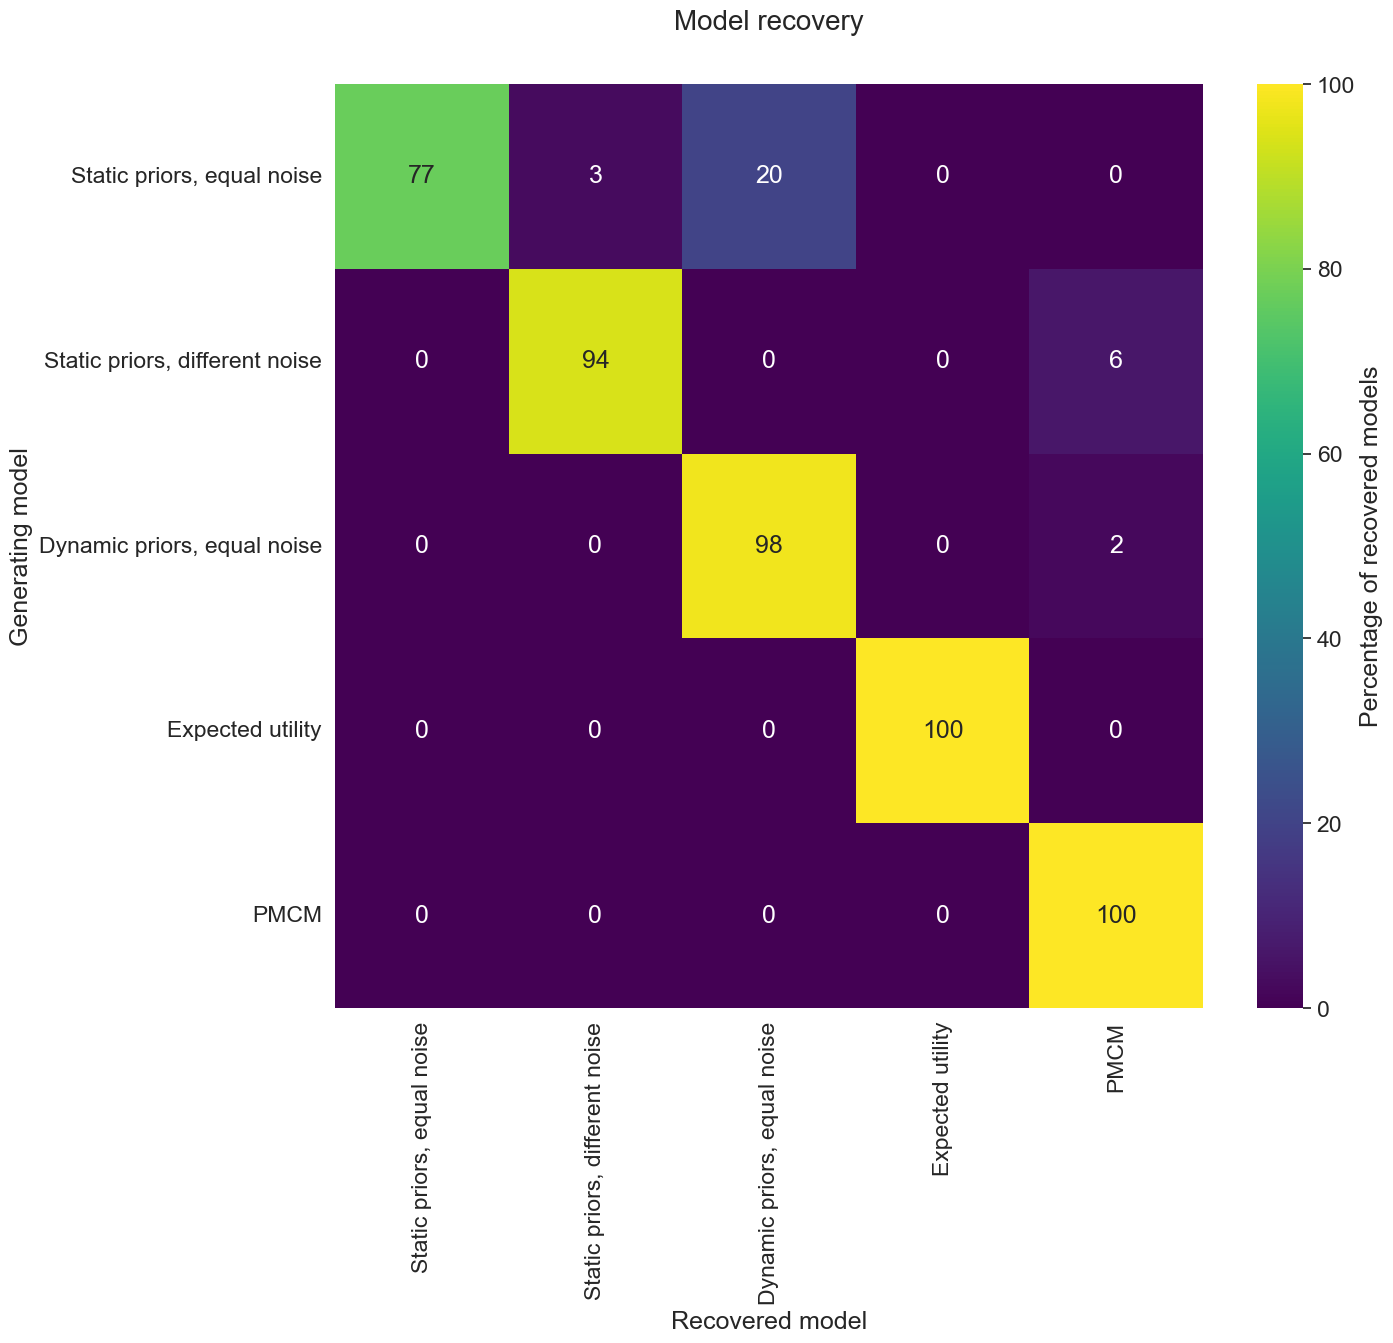

In [125]:

# User mapper to rename index levels generating_model and recovered_model
data.rename(index=mapper, level='generating_model', inplace=True)
data.rename(index=mapper, level='recovered_model', inplace=True)


order = ['klw', 'static_priors', 'static_noise', 'eu', 'pmrc']
order = [mapper[o] for o in order]

sns.set(font_scale=1.5)
tmp = (data.xs(0, level='rank').groupby(['generating_model', 'recovered_model']).size() / data.groupby(['generating_model']).size() *5 * 100).round().unstack('recovered_model').fillna(0.0).astype(int)

tmp = tmp.loc[order, order]
g = sns.heatmap(tmp, cmap='viridis', annot=True, fmt="d")

g.set_xlabel('Recovered model')
g.set_ylabel('Generating model')

g.set_title('Model recovery', y=1.05, fontsize=20)


# Set title of colorbar
cbar = g.collections[0].colorbar
cbar.set_label('Percentage of recovered models')


# Set figure size
g.figure.set_size_inches(14, 12)


import matplotlib.pyplot as plt
plt.savefig(op.join(bids_folder, 'derivatives', 'figures', 'model_recovry.pdf'), bbox_inches='tight')
plt.savefig(op.join(bids_folder, 'derivatives', 'figures', 'model_recovry.png'), bbox_inches='tight', dpi=300)

In [112]:
tmp.unstack(-1)

recovered_model,"Dynamic priors, equal noise",Expected utility,PMCM,"Static priors, different noise","Static priors, equal noise)"
generating_model,,,,,
"Dynamic priors, equal noise",98.0,NaN,2.0,NaN,NaN
Expected utility,NaN,100.0,NaN,NaN,NaN
PMCM,NaN,NaN,100.0,NaN,NaN
"Static priors, different noise",NaN,NaN,6.0,94.0,NaN
"Static priors, equal noise)",20.0,NaN,NaN,3.0,77.0


<Axes: xlabel='recovered_model', ylabel='generating_model'>

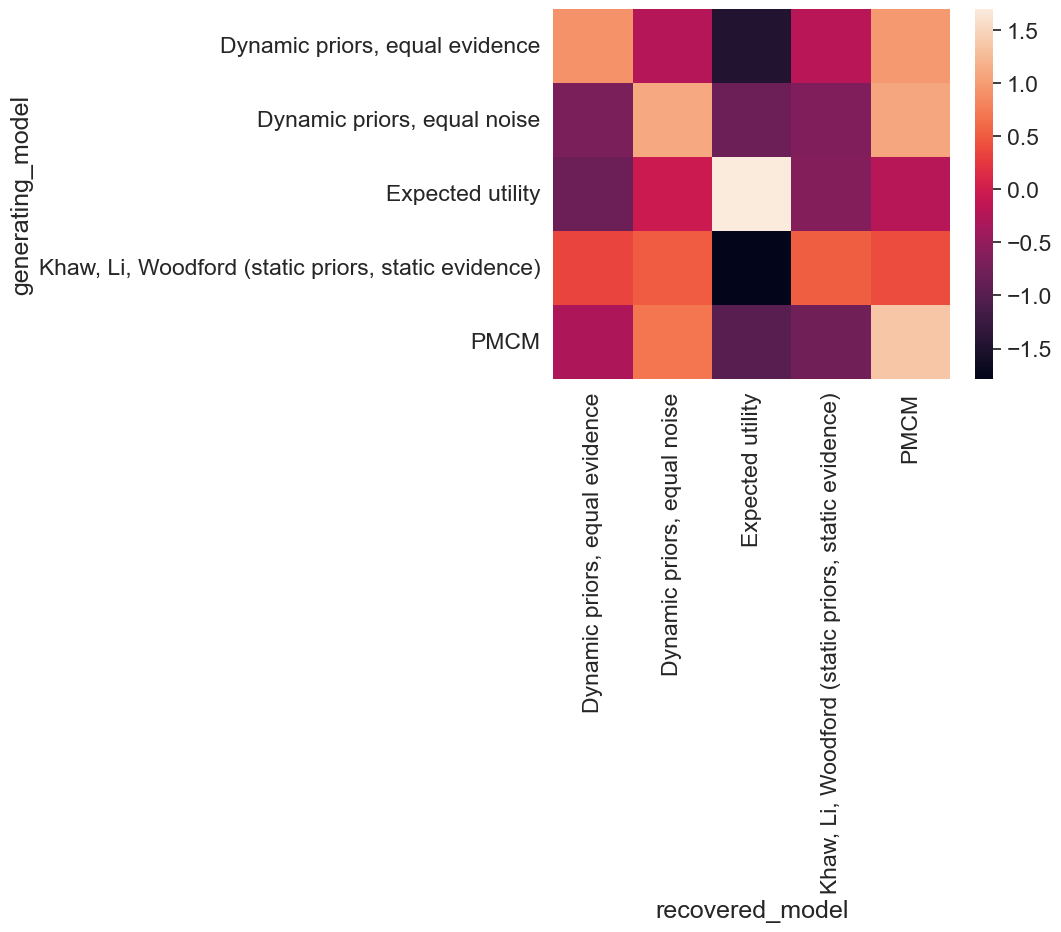

In [89]:
tmp = data.groupby(['generating_model', 'recovered_model'])['elpd_loo'].mean().unstack('recovered_model')

# zscore rows
tmp = (tmp - tmp.mean(axis=1).values[:, None]) / tmp.std(axis=1).values[:, None]
sns.heatmap(tmp)

In [35]:
data.groupby(['generating_model', 'recovered_model'])[['elpd_loo']].mean()

elpd_loo
generating_model recovered_model             
eu               eu              -7008.424721
                 klw             -7181.944344
                 pmrc            -7151.287848
                 static_noise    -7138.637244
                 static_priors   -7196.439931
klw              eu              -6968.250422
                 klw             -6790.203626
                 pmrc            -6800.260153
                 static_noise    -6791.989814
                 static_priors   -6804.018158
pmrc             eu              -6704.547638
                 klw             -6628.123057
                 pmrc            -5864.997419
                 static_noise    -6095.122107
                 static_priors   -6456.498261

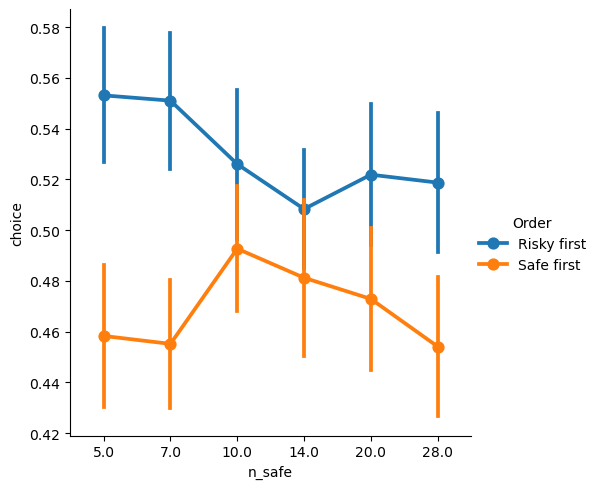

In [19]:
bids_folder = '/data/ds-risk'
df = load_simulated_data('klw', 6, bids_folder)

# df['real_risky_choice'] = df['real_choice'].where(~df['risky_first'], ~df['simulated_choice'])

sns.catplot(x='n_safe', y='choice',data=df.groupby(['subject', 'n_safe', 'Order'])[['choice']].mean().reset_index(), errorbar='se', hue='Order', kind='point')

In [ ]:
df

In [13]:
df.shape

(11520, 12)

  0%|          | 0/300 [00:00<?, ?it/s]

In [7]:
bids_folder = '/data/ds-risk'

def get_info(generating_model, recovering_model, simulation_index=1, bids_folder='/data/ds-risk'):

    df = load_simulated_data(generating_model, simulation_index, bids_folder)

    model = build_model(df, recovering_model)

    idata = op.join(bids_folder, 'derivatives', 'cogmodels', 'model_recovery', 'traces', f'generating-{generating_model}_recovering-{recovering_model}_{simulation_index}.netcdf')
    idata = az.from_netcdf(idata)

    with model.estimation_model:
        pm.compute_log_likelihood(idata)

    return idata

In [9]:
df = load_simulated_data('pmrc', 1, bids_folder)

In [10]:
df['choice'] = df['simulated_choice']
df['chose_risky'] = df['choice'].where(~df['risky_first'], ~df['choice'])

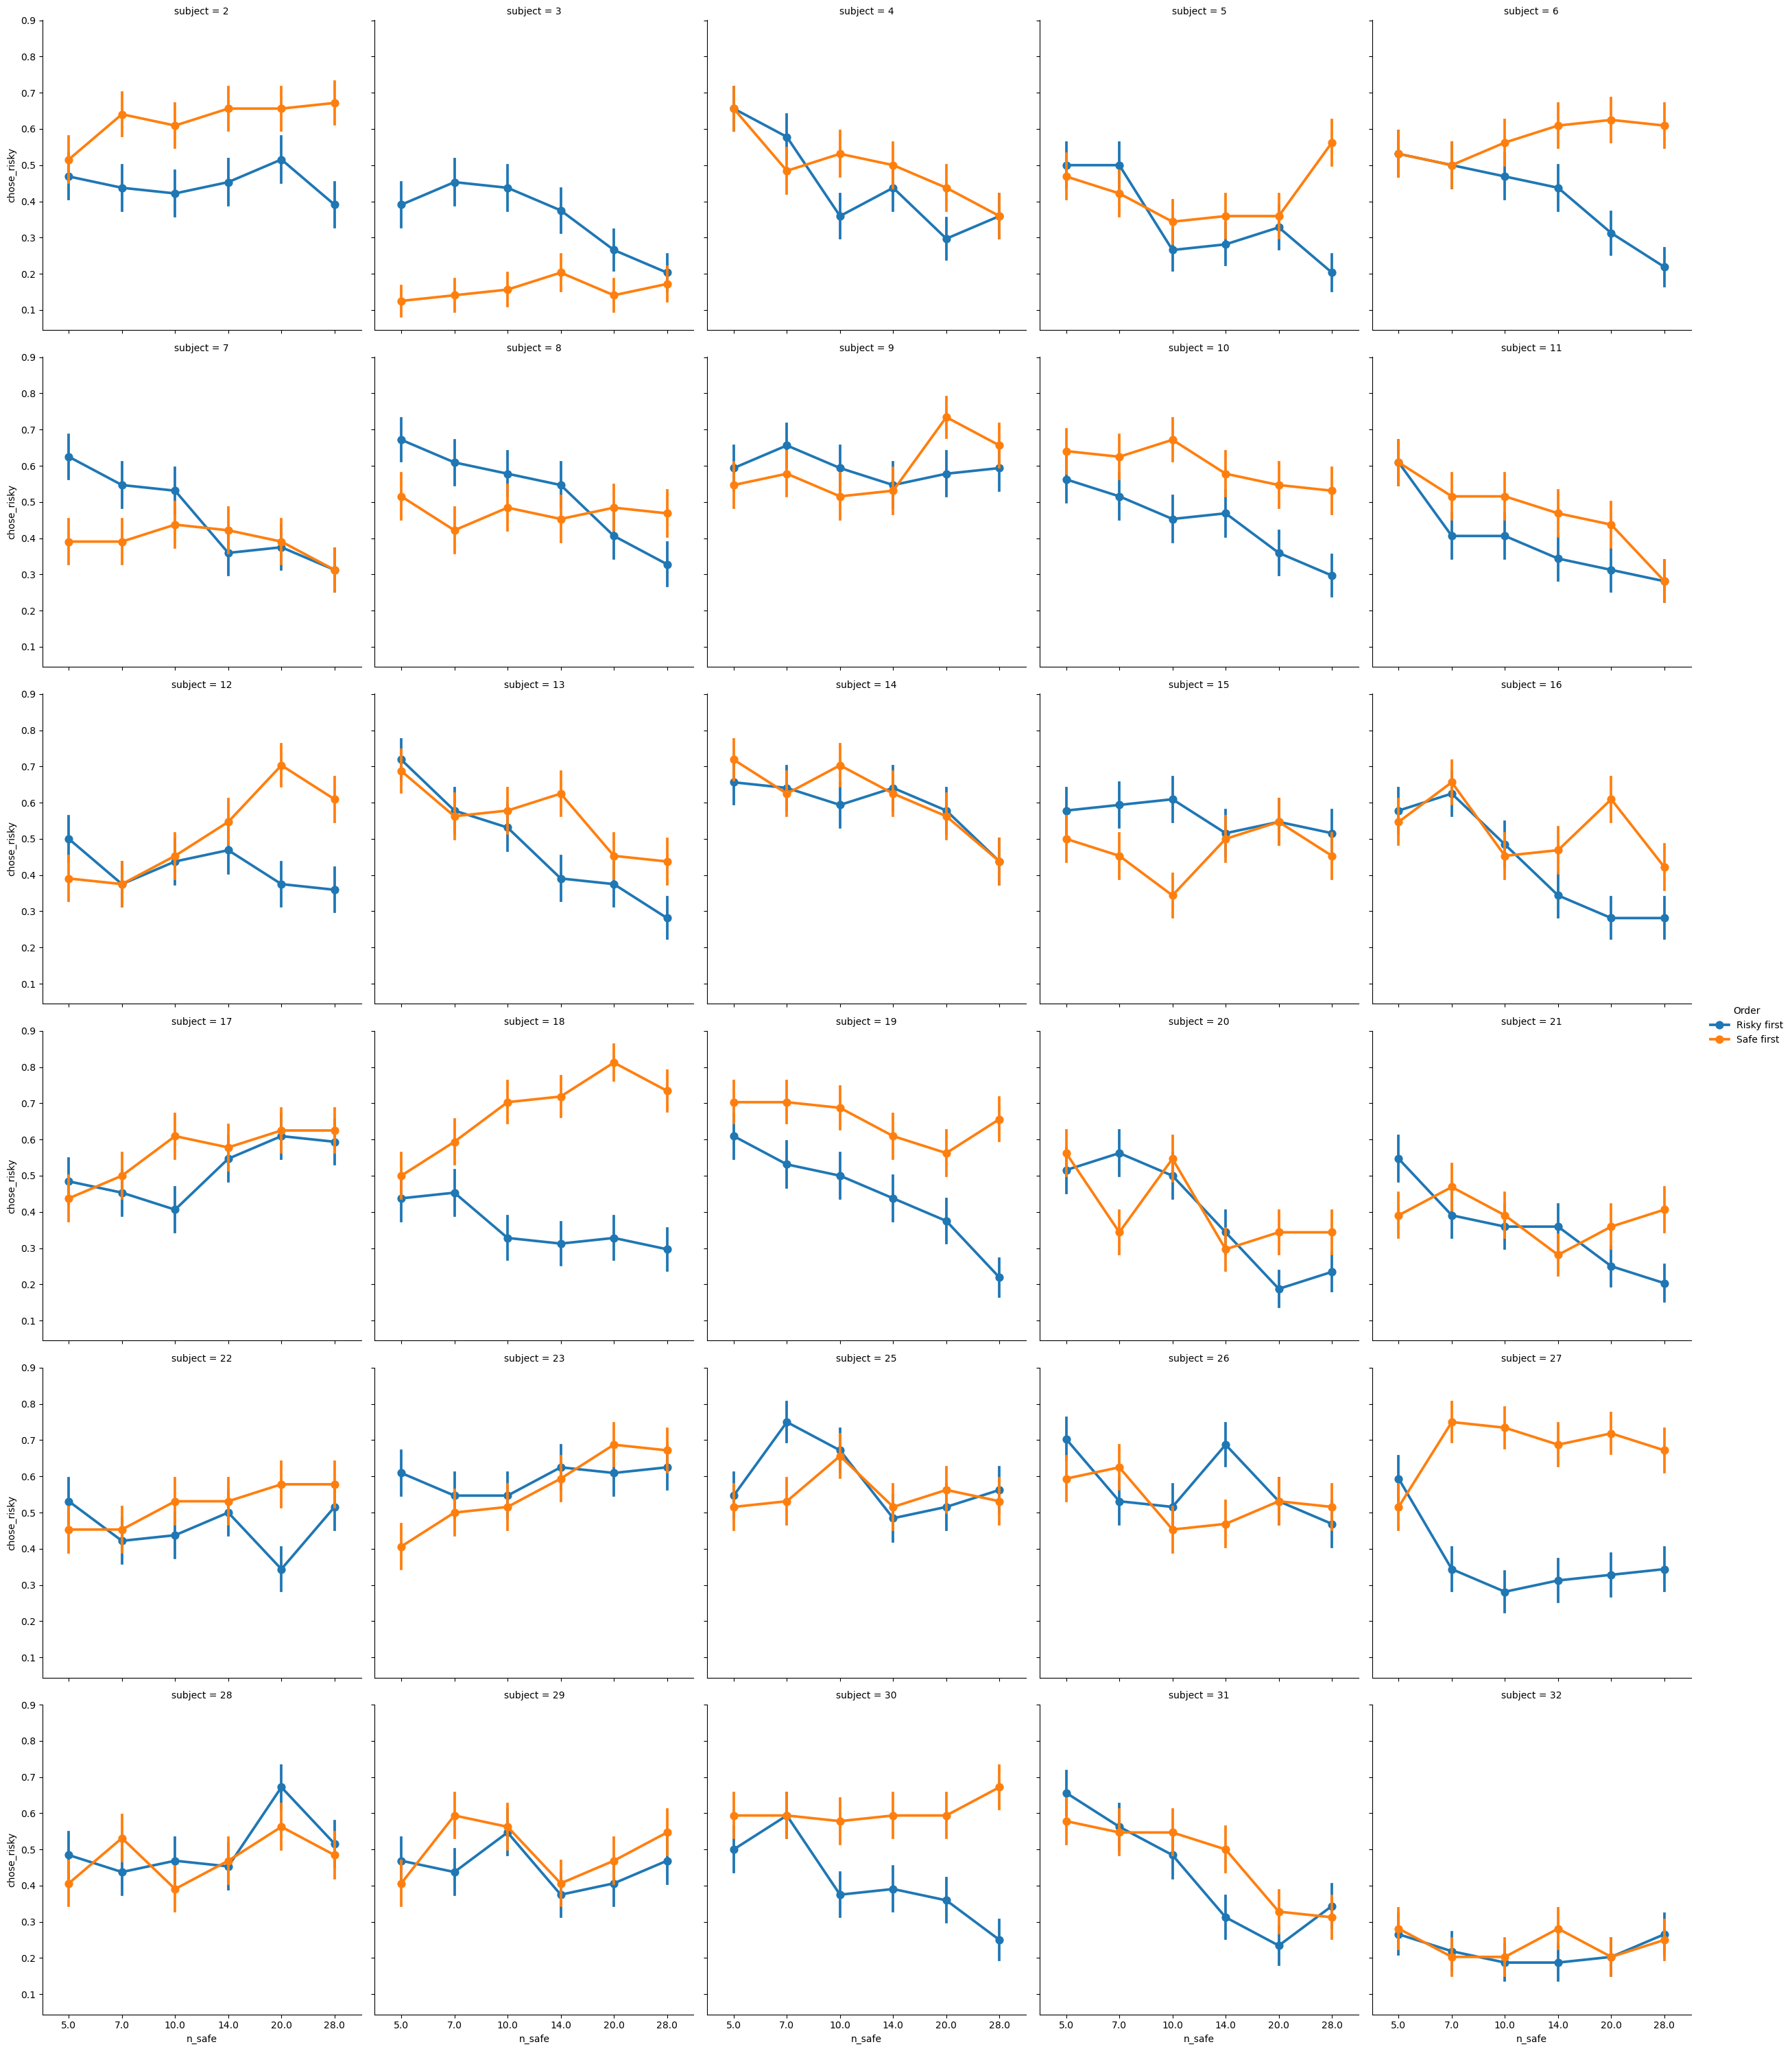

In [11]:
import seaborn as sns
# tmp = df.groupby(['subject', 'n_safe', 'Order'])[['chose_risky']].mean().reset_index()
tmp = df.copy()

sns.catplot(x='n_safe', y='chose_risky', data=tmp, errorbar='se', hue='Order', kind='point', col='subject', col_wrap=5)

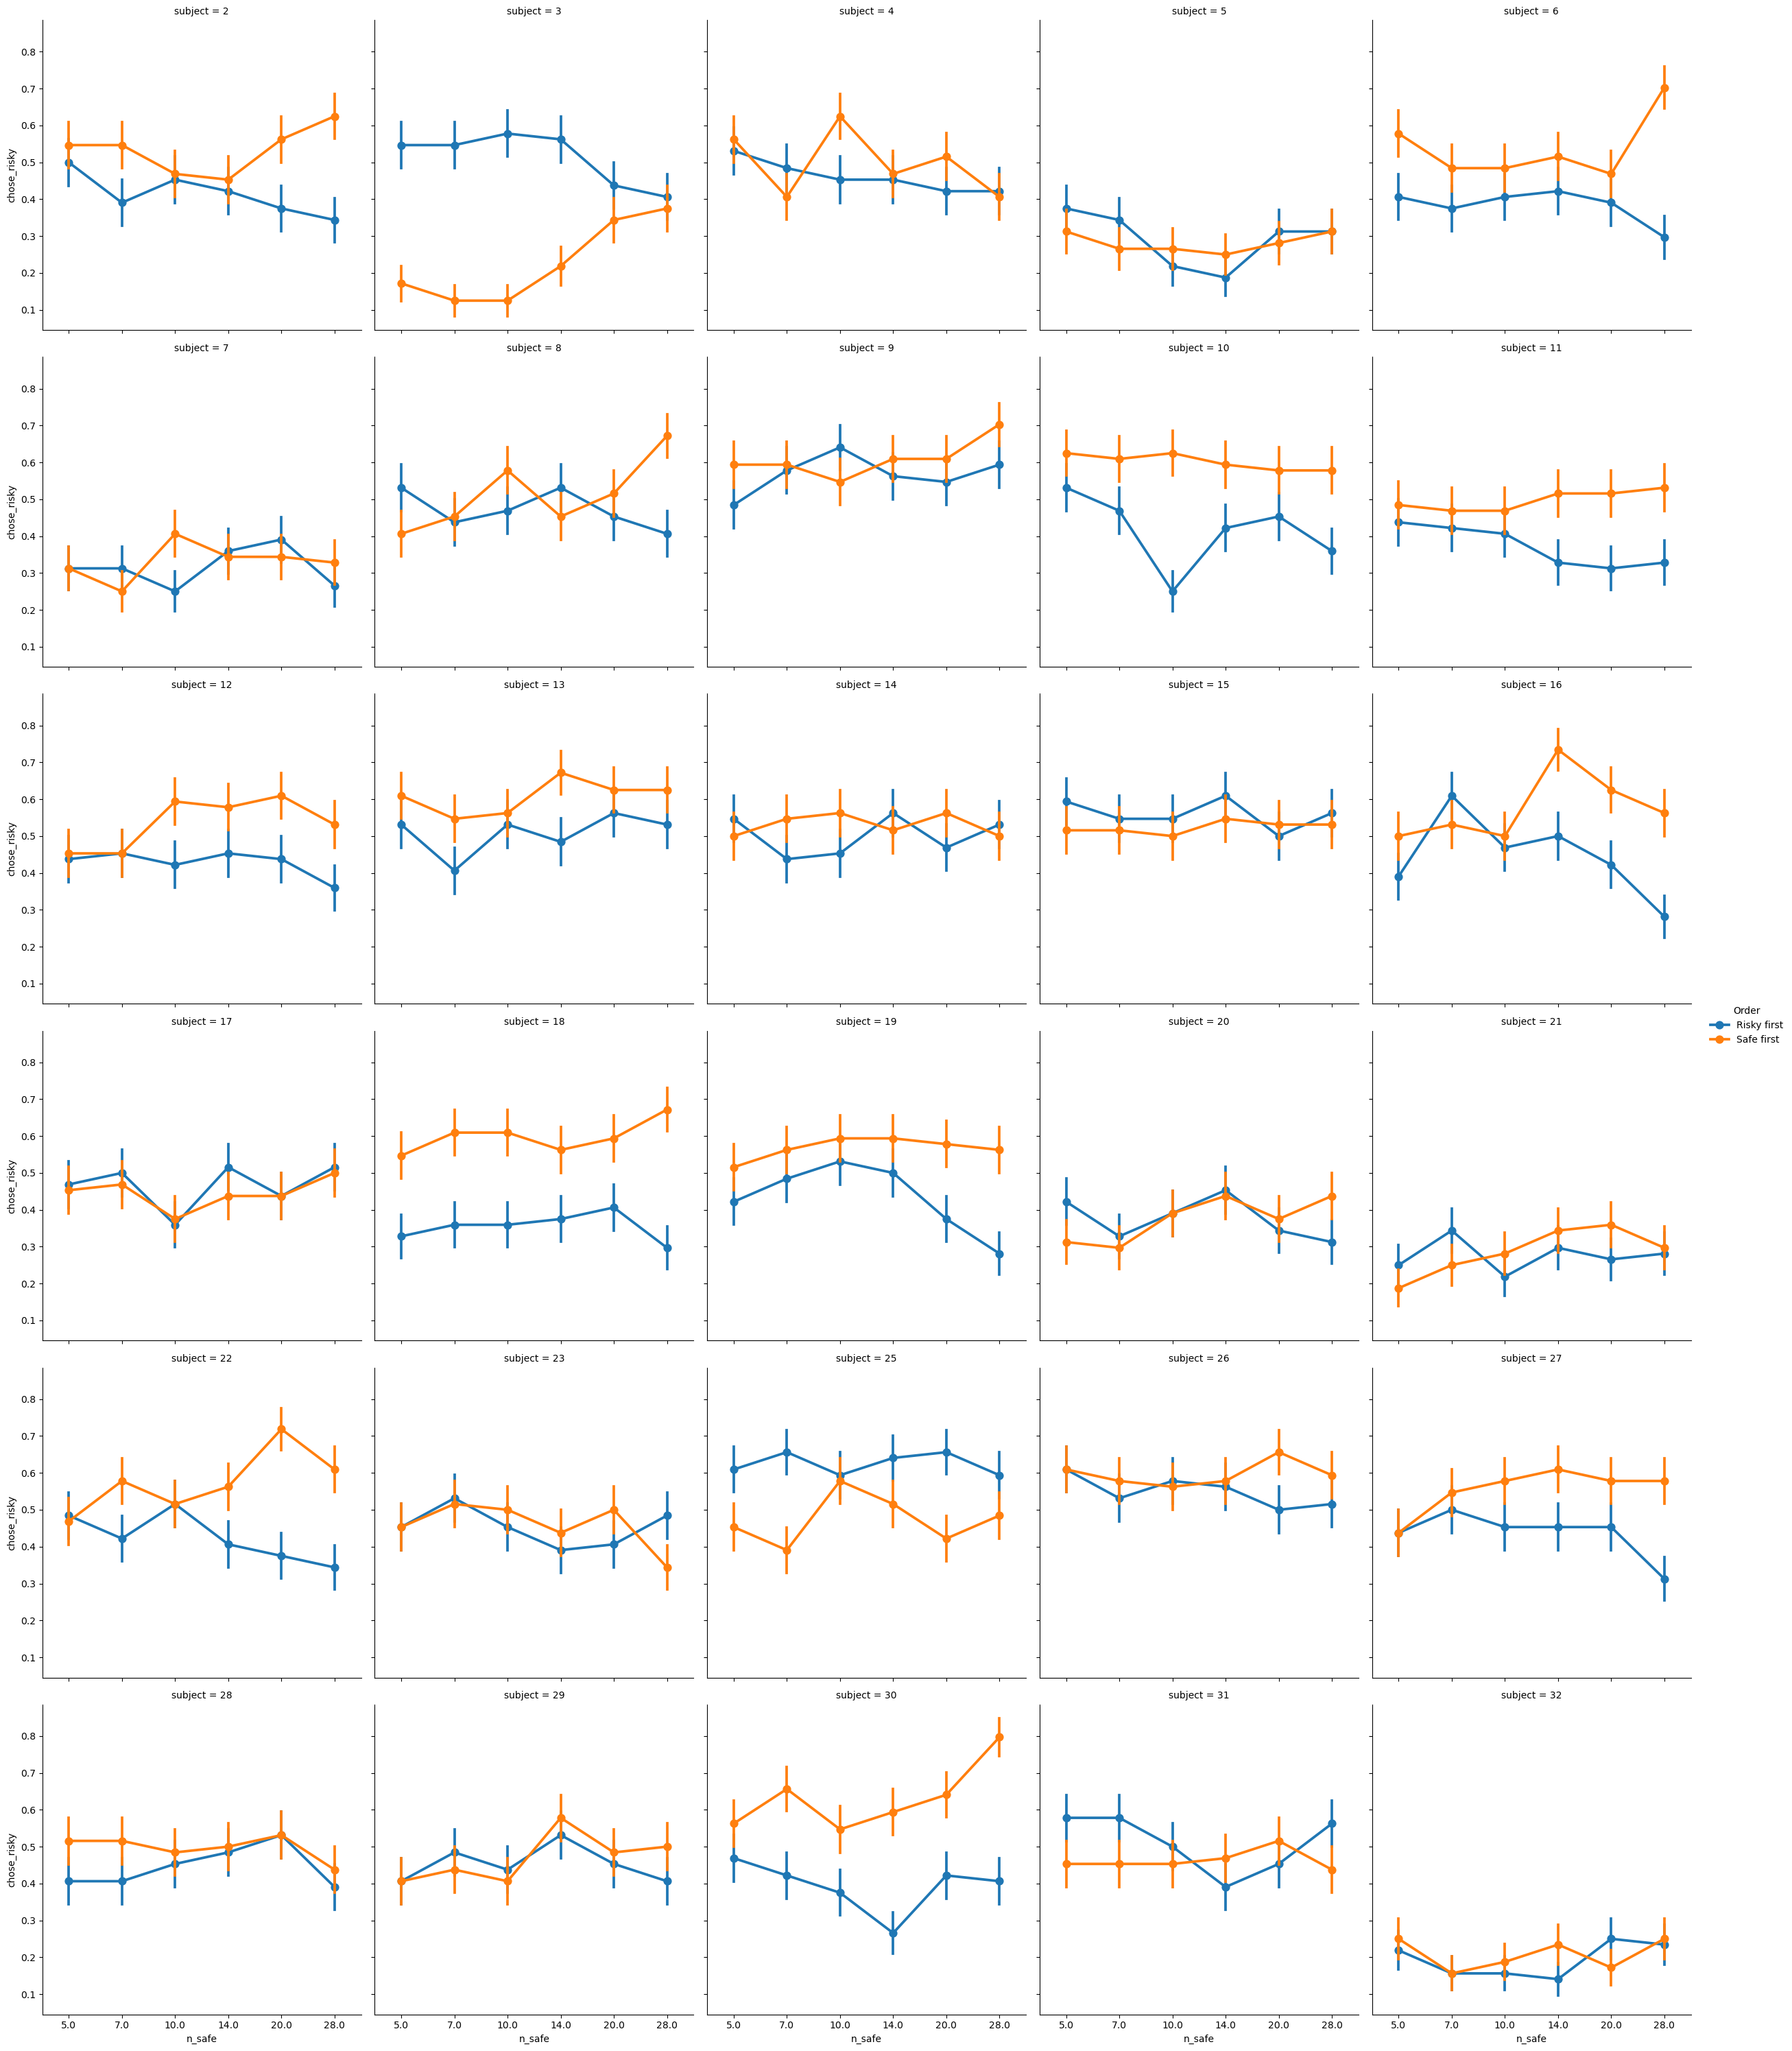

In [12]:
df = load_simulated_data('static_priors', 1, bids_folder)

sns.catplot(x='n_safe', y='chose_risky', data=df, errorbar='se', hue='Order', kind='point', col='subject', col_wrap=5)

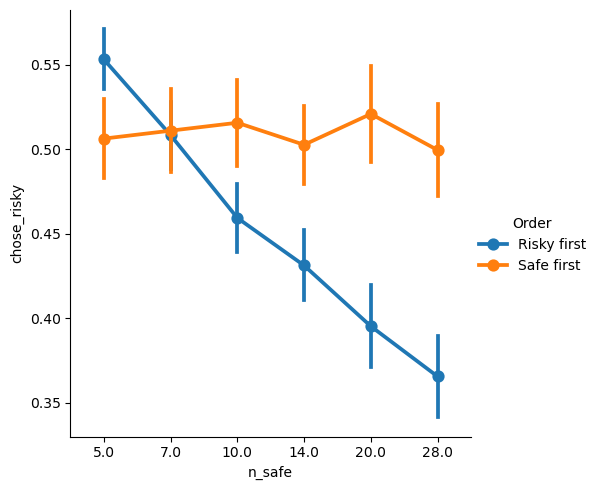

In [35]:
df = load_simulated_data('pmrc', 1, bids_folder)

sns.catplot(x='n_safe', y='chose_risky',
            data=df.groupby(['subject', 'n_safe', 'Order'])[['chose_risky']].mean().reset_index(), errorbar='se', hue='Order', kind='point')

In [54]:
from risk_experiment.cogmodels.fit_model import get_data, build_model
data = get_data('12', None, bids_folder, None)

100%|██████████| 30/30 [00:01<00:00, 23.26it/s]


In [52]:
df = load_simulated_data('pmrc', 1, bids_folder)

In [56]:
from bauer.models import RiskModel

In [63]:
model_label = 'klw'
n_simulations = 1

In [100]:
data = get_data(model_label, None, bids_folder, None)
model = build_model(model_label, data, None)
idata = az.from_netcdf(f'/data/ds-risk/derivatives/cogmodels/model-{model_label}_trace.netcdf')

pars = model.free_parameters.keys()
pars_full_3t = pd.concat([model.forward_transform(idata.posterior[par].to_dataframe().xs('Intercept', 0, f'{par}_regressors'), par) for par in pars], axis=1).groupby('subject').mean()
pars_full_7t = pd.concat([model.forward_transform(idata.posterior[par].to_dataframe().unstack(level=-1).sum(1).to_frame(par), par) for par in pars], axis=1).groupby('subject').mean()
pars_full_3t.index = pars_full_3t.index.astype(int)
pars_full_7t.index = pars_full_7t.index.astype(int)

parameters = pd.concat((pars_full_3t, pars_full_7t), keys=['3t', '7t'], names=['session'], axis=0)
parameters = parameters.groupby('subject').mean()

# Make sure the level 'subject' is an integer
data.index = data.index.set_levels(data.index.levels[0].astype(int), level=0)

if model_label == 'eu':
    simulation_model = ExpectedUtilityRiskModel(data)
elif model_label == '12':
    simulation_model = RiskModel(data, fit_seperate_evidence_sd=True, prior_estimate='full')
elif model_label == 'klw':
    simulation_model = RiskModel(data, fit_seperate_evidence_sd=False, prior_estimate='klw')

simulated_data = simulation_model.simulate(data[['n1', 'p1', 'n2', 'p2']].droplevel([1, 2],axis=0), parameters, n_samples=n_simulations)

100%|██████████| 30/30 [00:01<00:00, 21.44it/s]


In [103]:
simulated_data.shape

(23040, 5)

In [107]:
paradigm

rt  uncertainty  z_uncertainty  \
subject session run trial_nr                                         
2       3t2     1   1         1.096017          1.0      -1.508735   
                    2         1.324627          1.0      -1.508735   
                    3         1.224786          3.0       0.997077   
                    4         1.125724          3.0       0.997077   
                    5         1.175374          3.0       0.997077   
...                                ...          ...            ...   
32      7t2     8   188       0.574373          1.0      -0.535805   
                    189       0.424887          2.0       1.856628   
                    190       0.508297          1.0      -0.535805   
                    191       0.508506          1.0      -0.535805   
                    192       0.542275          2.0       1.856628   

                             median_split_uncertainty    n1    n2  prob1  \
subject session run trial_nr                                               
2       3t2     1   1                 low uncertainty   5.0   5.0   0.55   
                    2                 low uncertainty   7.0   7.0   0.55   
                    3                high uncertainty  37.0  20.0   0.55   
                    4                high uncertainty  47.0  20.0   0.55   
                    5                high uncertainty  18.0  10.0   0.55   
...                                               ...   ...   ...    ...   
32      7t2     8   188               low uncertainty  26.0  10.0   0.55   
                    189              high uncertainty  15.0   7.0   0.55   
                    190               low uncertainty  34.0  28.0   0.55   
                    191               low uncertainty  34.0  28.0   0.55   
                    192              high uncertainty  28.0   7.0   0.55   

                              prob2    p1   p2  ...  risky_first  chose_risky  \
subject session run trial_nr                    ...                             
2       3t2     1   1           1.0  0.55  1.0  ...         True        False   
                    2           1.0  0.55  1.0  ...         True        False   
                    3           1.0  0.55  1.0  ...         True        False   
                    4           1.0  0.55  1.0  ...         True         True   
                    5           1.0  0.55  1.0  ...         True        False   
...                             ...   ...  ...  ...          ...          ...   
32      7t2     8   188         1.0  0.55  1.0  ...         True        False   
                    189         1.0  0.55  1.0  ...         True        False   
                    190         1.0  0.55  1.0  ...         True        False   
                    191         1.0  0.55  1.0  ...         True        False   
                    192         1.0  0.55  1.0  ...         True        False   

                                    Order  n_risky  n_safe      frac  \
subject session run trial_nr                                           
2       3t2     1   1         Risky first      5.0     5.0  1.000000   
                    2         Risky first      7.0     7.0  1.000000   
                    3         Risky first     37.0    20.0  1.850000   
                    4         Risky first     47.0    20.0  2.350000   
                    5         Risky first     18.0    10.0  1.800000   
...                                   ...      ...     ...       ...   
32      7t2     8   188       Risky first     26.0    10.0  2.600000   
                    189       Risky first     15.0     7.0  2.142857   
                    190       Risky first     34.0    28.0  1.214286   
                    191       Risky first     34.0    28.0  1.214286   
                    192       Risky first     28.0     7.0  4.000000   

                             log(risky/safe)  bin(risky/safe)   log(n1)  \
subject session run trial_nr                                          

In [112]:
simulated_data = simulation_model.simulate(paradigm[['n1', 'p1', 'n2', 'p2']], parameters, n_samples=n_simulations)
simulated_data

simulated_choice    n1    p1    n2   p2
subject session run trial_nr sample                                         
2       3t2     1   1        1                   True   5.0  0.55   5.0  1.0
                    2        1                   True   7.0  0.55   7.0  1.0
                    3        1                  False  37.0  0.55  20.0  1.0
                    4        1                  False  47.0  0.55  20.0  1.0
                    5        1                   True  18.0  0.55  10.0  1.0
...                                               ...   ...   ...   ...  ...
32      7t2     8   188      1                   True  26.0  0.55  10.0  1.0
                    189      1                   True  15.0  0.55   7.0  1.0
                    190      1                   True  34.0  0.55  28.0  1.0
                    191      1                   True  34.0  0.55  28.0  1.0
                    192      1                   True  28.0  0.55   7.0  1.0

[11520 rows x 5 columns]

In [101]:
paradigm = data.copy()
n_samples = 1

In [102]:
simulation_model.build_prediction_model(paradigm, parameters)

with model.prediction_model:
    data = pm.draw(simulation_model.prediction_model['ll_bernoulli'], draws=1)

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/gdehol/mambaforge/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3460, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_4637/840282413.py", line 3, in <module>
    with model.prediction_model:
AttributeError: 'RiskRegressionModel' object has no attribute 'prediction_model'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/gdehol/mambaforge/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 2057, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
  File "/Users/gdehol/mambaforge/lib/python3.10/site-packages/IPython/core/ultratb.py", line 1118, in structured_traceback
    return FormattedTB.structured_traceback(
  File "/Users/gdehol/mambaforge/lib/python3.10/site-packages/IPython/core/ultratb.py", line 1012, in structured_tracebac

In [94]:
import numpy as np

In [95]:
if not paradigm.index.name:
    paradigm.index.name = 'trial'

data = pd.DataFrame(data.T, index=paradigm.index, columns=pd.Index(np.arange(n_samples)+1, name='sample'))
data = data.stack().to_frame('simulated_choice').astype(bool)

In [96]:
data = data.join(paradigm)

In [97]:
data.shape

(11520, 25)

In [98]:
if ('subject' in paradigm.columns):
    data = data.set_index('subject', append=True)
    data = data.reorder_levels(['subject'] + list(data.index.names)[:-1])

In [99]:
data

simulated_choice        rt  uncertainty  \
subject session run trial_nr sample                                            
2       3t2     1   1        1                   True  1.096017          1.0   
                    2        1                  False  1.324627          1.0   
                    3        1                   True  1.224786          3.0   
                    4        1                  False  1.125724          3.0   
                    5        1                  False  1.175374          3.0   
...                                               ...       ...          ...   
32      7t2     8   188      1                   True  0.574373          1.0   
                    189      1                   True  0.424887          2.0   
                    190      1                   True  0.508297          1.0   
                    191      1                   True  0.508506          1.0   
                    192      1                   True  0.542275          2.0   

                                     z_uncertainty median_split_uncertainty  \
subject session run trial_nr sample                                           
2       3t2     1   1        1           -1.508735          low uncertainty   
                    2        1           -1.508735          low uncertainty   
                    3        1            0.997077         high uncertainty   
                    4        1            0.997077         high uncertainty   
                    5        1            0.997077         high uncertainty   
...                                            ...                      ...   
32      7t2     8   188      1           -0.535805          low uncertainty   
                    189      1            1.856628         high uncertainty   
                    190      1           -0.535805          low uncertainty   
                    191      1           -0.535805          low uncertainty   
                    192      1            1.856628         high uncertainty   

                                       n1    n2  prob1  prob2    p1  ...  \
subject session run trial_nr sample                                  ...   
2       3t2     1   1        1        5.0   5.0   0.55    1.0  0.55  ...   
                    2        1        7.0   7.0   0.55    1.0  0.55  ...   
                    3        1       37.0  20.0   0.55    1.0  0.55  ...   
                    4        1       47.0  20.0   0.55    1.0  0.55  ...   
                    5        1       18.0  10.0   0.55    1.0  0.55  ...   
...                                   ...   ...    ...    ...   ...  ...   
32      7t2     8   188      1       26.0  10.0   0.55    1.0  0.55  ...   
                    189      1       15.0   7.0   0.55    1.0  0.55  ...   
                    190      1       34.0  28.0   0.55    1.0  0.55  ...   
                    191      1       34.0  28.0   0.55    1.0  0.55  ...   
                    192      1       28.0   7.0   0.55    1.0  0.55  ...   

                                     risky_first  chose_risky        Order  \
subject session run trial_nr sample                                          
2       3t2     1   1        1              True        False  Risky first   
                    2        1              True        False  Risky first   
                    3        1              True        False  Risky first   
                    4        1              True         True  Risky first   
                    5        1              True        False  Risky first   
...                                          ...          ...          ...   
32      7t2     8   188      1              True        False  Risky first   
                    189      1              True        False  Risky first   
                    190      1              True        False  Risky first   
                    191      1              True        False  Risky first   
                    192      1             

In [74]:
simulated_data.shape

(11520,)

In [68]:
data

rt  uncertainty  z_uncertainty  \
subject session run trial_nr                                         
2       3t2     1   1         1.096017          1.0      -1.508735   
                    2         1.324627          1.0      -1.508735   
                    3         1.224786          3.0       0.997077   
                    4         1.125724          3.0       0.997077   
                    5         1.175374          3.0       0.997077   
...                                ...          ...            ...   
32      7t2     8   188       0.574373          1.0      -0.535805   
                    189       0.424887          2.0       1.856628   
                    190       0.508297          1.0      -0.535805   
                    191       0.508506          1.0      -0.535805   
                    192       0.542275          2.0       1.856628   

                             median_split_uncertainty    n1    n2  prob1  \
subject session run trial_nr                                               
2       3t2     1   1                 low uncertainty   5.0   5.0   0.55   
                    2                 low uncertainty   7.0   7.0   0.55   
                    3                high uncertainty  37.0  20.0   0.55   
                    4                high uncertainty  47.0  20.0   0.55   
                    5                high uncertainty  18.0  10.0   0.55   
...                                               ...   ...   ...    ...   
32      7t2     8   188               low uncertainty  26.0  10.0   0.55   
                    189              high uncertainty  15.0   7.0   0.55   
                    190               low uncertainty  34.0  28.0   0.55   
                    191               low uncertainty  34.0  28.0   0.55   
                    192              high uncertainty  28.0   7.0   0.55   

                              prob2    p1   p2  ...  risky_first  chose_risky  \
subject session run trial_nr                    ...                             
2       3t2     1   1           1.0  0.55  1.0  ...         True        False   
                    2           1.0  0.55  1.0  ...         True        False   
                    3           1.0  0.55  1.0  ...         True        False   
                    4           1.0  0.55  1.0  ...         True         True   
                    5           1.0  0.55  1.0  ...         True        False   
...                             ...   ...  ...  ...          ...          ...   
32      7t2     8   188         1.0  0.55  1.0  ...         True        False   
                    189         1.0  0.55  1.0  ...         True        False   
                    190         1.0  0.55  1.0  ...         True        False   
                    191         1.0  0.55  1.0  ...         True        False   
                    192         1.0  0.55  1.0  ...         True        False   

                                    Order  n_risky  n_safe      frac  \
subject session run trial_nr                                           
2       3t2     1   1         Risky first      5.0     5.0  1.000000   
                    2         Risky first      7.0     7.0  1.000000   
                    3         Risky first     37.0    20.0  1.850000   
                    4         Risky first     47.0    20.0  2.350000   
                    5         Risky first     18.0    10.0  1.800000   
...                                   ...      ...     ...       ...   
32      7t2     8   188       Risky first     26.0    10.0  2.600000   
                    189       Risky first     15.0     7.0  2.142857   
                    190       Risky first     34.0    28.0  1.214286   
                    191       Risky first     34.0    28.0  1.214286   
                    192       Risky first     28.0     7.0  4.000000   

                             log(risky/safe)  bin(risky/safe)   log(n1)  \
subject session run trial_nr                                          

In [69]:
simulated_data

simulated_choice        rt  uncertainty  \
subject trial_nr sample                                            
2       1        1                  False  1.096017          1.0   
                 1                  False  1.544193          3.0   
                 1                   True  1.096017          1.0   
                 1                   True  1.544193          3.0   
        2        1                   True  1.324627          1.0   
...                                   ...       ...          ...   
32      191      1                   True  0.508506          1.0   
        192      1                   True  0.648526          1.0   
                 1                   True  0.542275          2.0   
                 1                  False  0.648526          1.0   
                 1                  False  0.542275          2.0   

                         z_uncertainty median_split_uncertainty    n1    n2  \
subject trial_nr sample                                                       
2       1        1           -1.508735          low uncertainty   5.0   5.0   
                 1            1.190537         high uncertainty  19.0  10.0   
                 1           -1.508735          low uncertainty   5.0   5.0   
                 1            1.190537         high uncertainty  19.0  10.0   
        2        1           -1.508735          low uncertainty   7.0   7.0   
...                                ...                      ...   ...   ...   
32      191      1           -0.535805          low uncertainty  34.0  28.0   
        192      1           -0.694449          low uncertainty  79.0  28.0   
                 1            1.856628         high uncertainty  28.0   7.0   
                 1           -0.694449          low uncertainty  79.0  28.0   
                 1            1.856628         high uncertainty  28.0   7.0   

                         prob1  prob2    p1  ...  risky_first  chose_risky  \
subject trial_nr sample                      ...                             
2       1        1        0.55    1.0  0.55  ...         True        False   
                 1        0.55    1.0  0.55  ...         True        False   
                 1        0.55    1.0  0.55  ...         True        False   
                 1        0.55    1.0  0.55  ...         True        False   
        2        1        0.55    1.0  0.55  ...         True        False   
...                        ...    ...   ...  ...          ...          ...   
32      191      1        0.55    1.0  0.55  ...         True        False   
        192      1        0.55    1.0  0.55  ...         True        False   
                 1        0.55    1.0  0.55  ...         True        False   
                 1        0.55    1.0  0.55  ...         True        False   
                 1        0.55    1.0  0.55  ...         True        False   

                               Order  n_risky  n_safe      frac  \
subject trial_nr sample                                           
2       1        1       Risky first      5.0     5.0  1.000000   
                 1       Risky first     19.0    10.0  1.900000   
                 1       Risky first      5.0     5.0  1.000000   
                 1       Risky first     19.0    10.0  1.900000   
        2        1       Risky first      7.0     7.0  1.000000   
...                              ...      ...     ...       ...   
32      191      1       Risky first     34.0    28.0  1.214286   
        192      1       Risky first     79.0    28.0  2.821429   
                 1       Risky first     28.0     7.0  4.000000   
                 1       Risky first     79.0    28.0  2.821429   
                 1       Risky first     28.0     7.0  4.000000   

                         log(risky/safe) bin(risky/safe)   log(n1)  session  
subject trial_nr sample                                                      
2       1        1              0.000000             1.0  1.609438   

In [67]:
data.shape

(11520, 24)

In [66]:
simulated_data.shape

(23040, 25)

In [51]:
df.groupby(['subject', 'session']).size()

subject  session
2        3t2        384
         7t2        384
3        3t2        384
         7t2        384
4        3t2        384
         7t2        384
5        3t2        384
         7t2        384
6        3t2        384
         7t2        384
7        3t2        384
         7t2        384
8        3t2        384
         7t2        384
9        3t2        384
         7t2        384
10       3t2        384
         7t2        384
11       3t2        384
         7t2        384
12       3t2        384
         7t2        384
13       3t2        384
         7t2        384
14       3t2        384
         7t2        384
15       3t2        384
         7t2        384
16       3t2        384
         7t2        384
17       3t2        384
         7t2        384
18       3t2        384
         7t2        384
19       3t2        384
         7t2        384
20       3t2        384
         7t2        384
21       3t2        384
         7t2        384
22       3t2        384

In [50]:
data.drop('session', axis=1).groupby(['subject', 'session']).size()

subject  session
02       3t2        192
         7t2        192
03       3t2        192
         7t2        192
04       3t2        192
         7t2        192
05       3t2        192
         7t2        192
06       3t2        192
         7t2        192
07       3t2        192
         7t2        192
08       3t2        192
         7t2        192
09       3t2        192
         7t2        192
10       3t2        192
         7t2        192
11       3t2        192
         7t2        192
12       3t2        192
         7t2        192
13       3t2        192
         7t2        192
14       3t2        192
         7t2        192
15       3t2        192
         7t2        192
16       3t2        192
         7t2        192
17       3t2        192
         7t2        192
18       3t2        192
         7t2        192
19       3t2        192
         7t2        192
20       3t2        192
         7t2        192
21       3t2        192
         7t2        192
22       3t2        192

In [42]:
df.groupby(['subject', 'session']).size()

subject  session
2        3t2        384
         7t2        384
3        3t2        384
         7t2        384
4        3t2        384
         7t2        384
5        3t2        384
         7t2        384
6        3t2        384
         7t2        384
7        3t2        384
         7t2        384
8        3t2        384
         7t2        384
9        3t2        384
         7t2        384
10       3t2        384
         7t2        384
11       3t2        384
         7t2        384
12       3t2        384
         7t2        384
13       3t2        384
         7t2        384
14       3t2        384
         7t2        384
15       3t2        384
         7t2        384
16       3t2        384
         7t2        384
17       3t2        384
         7t2        384
18       3t2        384
         7t2        384
19       3t2        384
         7t2        384
20       3t2        384
         7t2        384
21       3t2        384
         7t2        384
22       3t2        384

In [114]:
df

simulated_choice        rt  uncertainty  \
subject trial_nr sample                                            
2       1        1                   True  1.096017          1.0   
                 1                   True  1.544193          3.0   
        2        1                   True  1.324627          1.0   
                 1                   True  0.890433          3.0   
        3        1                   True  1.224786          3.0   
...                                   ...       ...          ...   
32      190      1                   True  0.508297          1.0   
        191      1                   True  0.836195          2.0   
                 1                   True  0.508506          1.0   
        192      1                   True  0.648526          1.0   
                 1                   True  0.542275          2.0   

                         z_uncertainty median_split_uncertainty     n1    n2  \
subject trial_nr sample                                                        
2       1        1           -1.508735          low uncertainty    5.0   5.0   
                 1            1.190537         high uncertainty   19.0  10.0   
        2        1           -1.508735          low uncertainty    7.0   7.0   
                 1            1.190537         high uncertainty   98.0  28.0   
        3        1            0.997077         high uncertainty   37.0  20.0   
...                                ...                      ...    ...   ...   
32      190      1           -0.535805          low uncertainty   34.0  28.0   
        191      1            1.366852         high uncertainty  102.0  28.0   
                 1           -0.535805          low uncertainty   34.0  28.0   
        192      1           -0.694449          low uncertainty   79.0  28.0   
                 1            1.856628         high uncertainty   28.0   7.0   

                         prob1  prob2    p1  ...  chose_risky        Order  \
subject trial_nr sample                      ...                             
2       1        1        0.55    1.0  0.55  ...        False  Risky first   
                 1        0.55    1.0  0.55  ...        False  Risky first   
        2        1        0.55    1.0  0.55  ...        False  Risky first   
                 1        0.55    1.0  0.55  ...        False  Risky first   
        3        1        0.55    1.0  0.55  ...        False  Risky first   
...                        ...    ...   ...  ...          ...          ...   
32      190      1        0.55    1.0  0.55  ...        False  Risky first   
        191      1        0.55    1.0  0.55  ...        False  Risky first   
                 1        0.55    1.0  0.55  ...        False  Risky first   
        192      1        0.55    1.0  0.55  ...        False  Risky first   
                 1        0.55    1.0  0.55  ...        False  Risky first   

                         n_risky  n_safe      frac  log(risky/safe)  \
subject trial_nr sample                                               
2       1        1           5.0     5.0  1.000000         0.000000   
                 1          19.0    10.0  1.900000         0.641854   
        2        1           7.0     7.0  1.000000         0.000000   
                 1          98.0    28.0  3.500000         1.252763   
        3        1          37.0    20.0  1.850000         0.615186   
...                          ...     ...       ...              ...   
32      190      1          34.0    28.0  1.214286         0.194156   
        191      1         102.0    28.0  3.642857         1.292768   
                 1          34.0    28.0  1.214286         0.194156   
        192      1          79.0    28.0  2.821429         1.037243   
                 1          28.0     7.0  4.000000         1.386294   

                         bin(risky/safe)   log(n1)  session  real_choice  
subject trial_nr sample                                                   
2       1 

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/gdehol/mambaforge/lib/python3.10/site-packages/pandas/core/indexes/base.py", line 3791, in get_loc
    return self._engine.get_loc(casted_key)
  File "index.pyx", line 152, in pandas._libs.index.IndexEngine.get_loc
  File "index.pyx", line 181, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7080, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7088, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyError: 'risky_first'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/Users/gdehol/mambaforge/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3460, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_34555/2366000697.py", line 2, in <module>
    df = load_simulate

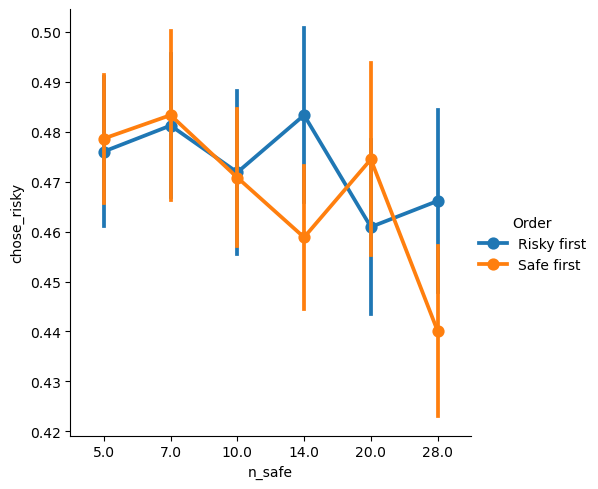

In [14]:
df = load_simulated_data('eu', 1, bids_folder)

sns.catplot(x='n_safe', y='chose_risky',
            data=df.groupby(['subject', 'n_safe', 'Order'])[['chose_risky']].mean().reset_index(), errorbar='se', hue='Order', kind='point')

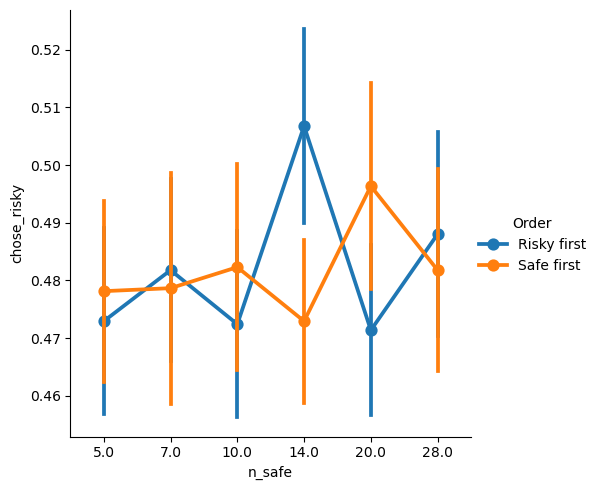

In [15]:
df = load_simulated_data('klw', 1, bids_folder)

sns.catplot(x='n_safe', y='chose_risky',
            data=df.groupby(['subject', 'n_safe', 'Order'])[['chose_risky']].mean().reset_index(), errorbar='se', hue='Order', kind='point')

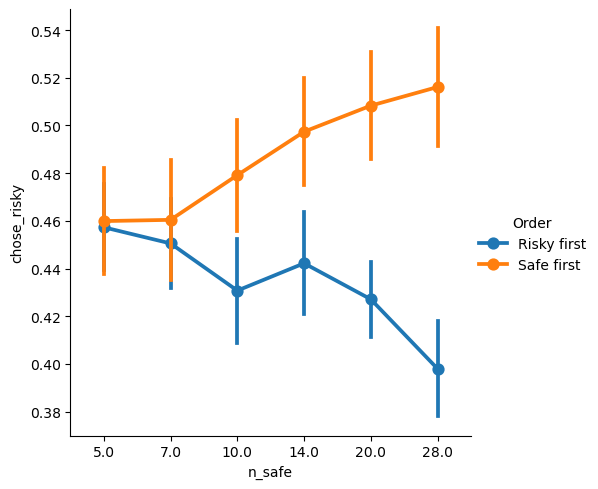

In [16]:
df = load_simulated_data('static_priors', 1, bids_folder)

sns.catplot(x='n_safe', y='chose_risky',
            data=df.groupby(['subject', 'n_safe', 'Order'])[['chose_risky']].mean().reset_index(), errorbar='se', hue='Order', kind='point')

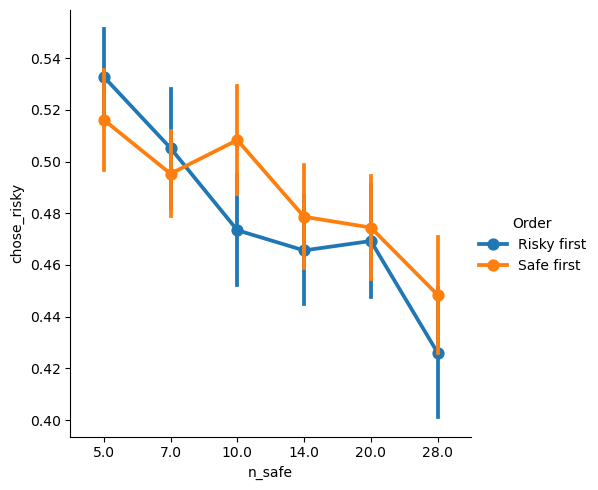

In [17]:
df = load_simulated_data('static_noise', 1, bids_folder)

sns.catplot(x='n_safe', y='chose_risky',
            data=df.groupby(['subject', 'n_safe', 'Order'])[['chose_risky']].mean().reset_index(), errorbar='se', hue='Order', kind='point')

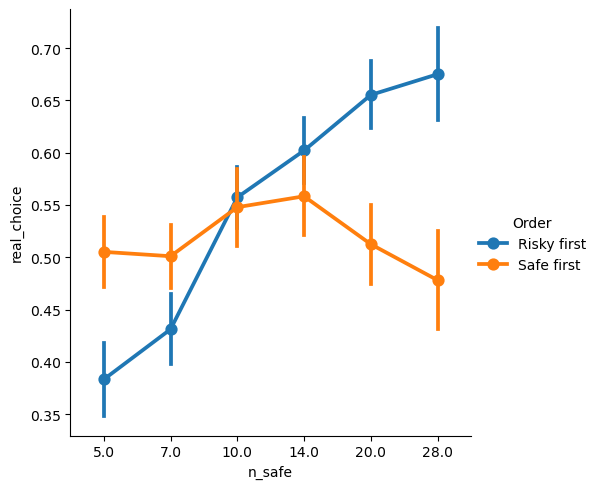

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_86159/1092149222.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.catplot(x='bin(risky/safe)', y='chose_risky', data=tmp, ci=68, hue='n_safe', col='Order', kind='point')


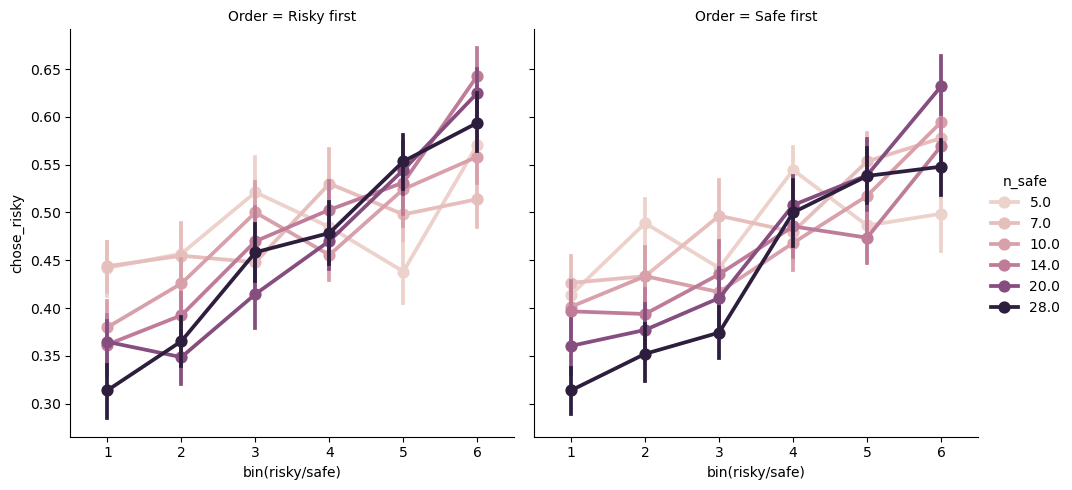

In [23]:
import seaborn as sns
tmp = df.groupby(['subject', 'bin(risky/safe)', 'Order', 'n_safe'])[['chose_risky']].mean().reset_index()

sns.catplot(x='bin(risky/safe)', y='chose_risky', data=tmp, ci=68, hue='n_safe', col='Order', kind='point')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_86159/2175367921.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.catplot(x='bin(risky/safe)', y='choice', data=tmp, ci=68, hue='n_safe', col='Order', kind='point')


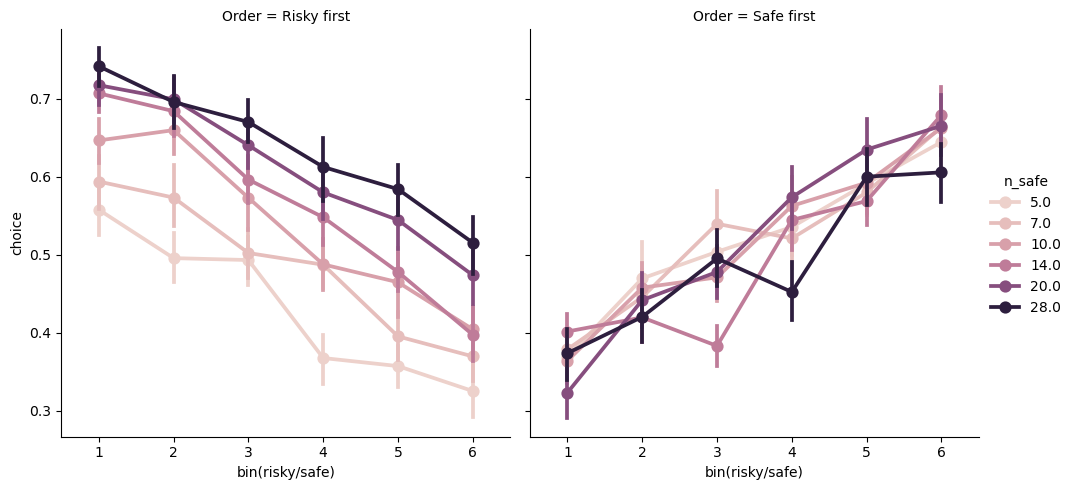

In [28]:
import seaborn as sns
tmp = df.groupby(['subject', 'bin(risky/safe)', 'Order', 'n_safe'])[['choice']].mean().reset_index()

sns.catplot(x='bin(risky/safe)', y='choice', data=tmp, ci=68, hue='n_safe', col='Order', kind='point')